# Dataset:
https://drive.google.com/drive/folders/1YonSQOAXXcva08W_dxgSeukkB0cG_PSR?usp=sharing

In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, pickle, warnings
import numpy as np
import nltk

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
import xgboost as xgb

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [3]:
# Display dataset original
df = pd.read_csv('BanglaEcomReviewCorpus.csv', sep=';')

print(f"Bentuk data: {df.shape}")
print(f'\nDistribusi sentiment:')
print(df['Sentiment'].value_counts())
df.head()

Bentuk data: (8685, 3)

Distribusi sentiment:
Sentiment
Positive    3012
Negative    2881
Neutral     2792
Name: count, dtype: int64


,Sentence,Sentiment,English Translation
0,দুর্দান্ত তবে হতাশাজনকভাবে ছোট,Neutral,Great but disappointingly small
1,ডিজাইনটি খুবই ফ্যাশনেবল,Positive,The design is very fashionable
2,খারাপভাবে ভাজা হয়েছিল যার ফলে অসম স্বাদের বি...,Negative,was poorly roasted resulting in uneven flavor...
3,পরিবারের সকলের জন্য উপযোগী,Positive,Suitable for the whole family
4,সেটের টুকরোগুলো খারাপভাবে আঁকা ছিল ধোঁয়া ও দ...,Negative,The set pieces were poorly painted with smudg...


In [4]:
# Drop sentence dalam Bahasa Bangla karena menggunakan translasi Bahasa Inggris
df = df.dropna(subset=['English Translation', 'Sentiment'])
df = df[['English Translation', 'Sentiment']].dropna()
df.columns = ['text', 'Sentiment']

print(f"Bentuk data yang diproses: {df.shape}")
print(f'\nDistribusi sentiment:')
print(df['Sentiment'].value_counts())
df.head()

Bentuk data yang diproses: (8685, 2)

Distribusi sentiment:
Sentiment
Positive    3012
Negative    2881
Neutral     2792
Name: count, dtype: int64


,text,Sentiment
0,Great but disappointingly small,Neutral
1,The design is very fashionable,Positive
2,was poorly roasted resulting in uneven flavor...,Negative
3,Suitable for the whole family,Positive
4,The set pieces were poorly painted with smudg...,Negative


In [5]:
# Cari jumlah baris yang duplikat textnya dan yang inkonsisten sentimentnya
print("Jumlah baris duplikat (full row):", df.duplicated().sum())
print("Jumlah teks duplikat (kolom 'English Translation' saja):", df.duplicated(subset=['text']).sum())

dup_text_diff_label = (
    df.groupby('text')['Sentiment']
    .nunique()
    .reset_index(name='n_unique_sentiment')
)
inconsistent = dup_text_diff_label[dup_text_diff_label['n_unique_sentiment'] > 1]
print(f"Jumlah teks identik dengan label sentimen berbeda: {len(inconsistent)}")
if len(inconsistent) > 0:
    display(df[df['text'].isin(inconsistent['text'])].sort_values('text').head(10))

Jumlah baris duplikat (full row): 88
Jumlah teks duplikat (kolom 'English Translation' saja): 93
Jumlah teks identik dengan label sentimen berbeda: 5


,text,Sentiment
5636,Available in different colors,Positive
8122,Available in different colors,Neutral
2821,Great value could have been better,Neutral
3254,Great value could have been better,Negative
1273,It can be cleaned easily,Positive
5954,It can be cleaned easily,Neutral
4483,Not very good,Neutral
5846,Not very good,Negative
2077,The color is right according to the season,Neutral
5746,The color is right according to the season,Positive


In [6]:
# Hapus baris duplikat namun tetap menyimpan baris yang pertama muncul dan hapus semua baris yang memiliki konflik sentimen
df = df.drop_duplicates(subset=['text', 'Sentiment'])

dup_mask = df.duplicated(subset=['text'], keep=False)
conflict_texts = df[dup_mask].groupby('text')['Sentiment'].nunique()
conflict_texts = conflict_texts[conflict_texts > 1].index
df = df[~df['text'].isin(conflict_texts)]

In [7]:
# Cari jumlah baris duplikat setelah diclean
print("Jumlah baris duplikat (full row):", df.duplicated().sum())
print("Jumlah teks duplikat (kolom 'English Translation' saja):", df.duplicated(subset=['text']).sum())

dup_text_diff_label = (
    df.groupby('text')['Sentiment']
    .nunique()
    .reset_index(name='n_unique_sentiment')
)
inconsistent = dup_text_diff_label[dup_text_diff_label['n_unique_sentiment'] > 1]
print(f"Jumlah teks identik dengan label sentimen berbeda: {len(inconsistent)}")
if len(inconsistent) > 0:
    display(df[df['text'].isin(inconsistent['text'])].sort_values('text').head(10))

Jumlah baris duplikat (full row): 0
Jumlah teks duplikat (kolom 'English Translation' saja): 0
Jumlah teks identik dengan label sentimen berbeda: 0


In [8]:
# Display dataset setelah dihapus duplikat dan konflik
print(f"Bentuk data yang diproses: {df.shape}")
print(f'\nDistribusi sentiment:')
print(df['Sentiment'].value_counts())
df.head()

Bentuk data yang diproses: (8587, 2)

Distribusi sentiment:
Sentiment
Positive    2955
Negative    2872
Neutral     2760
Name: count, dtype: int64


,text,Sentiment
0,Great but disappointingly small,Neutral
1,The design is very fashionable,Positive
2,was poorly roasted resulting in uneven flavor...,Negative
3,Suitable for the whole family,Positive
4,The set pieces were poorly painted with smudg...,Negative


In [9]:
# Cari nilai kosong dalam dataset
print("Missing Values")
print(df.isnull().sum())
print("-" * 50)

Missing Values
text         0
Sentiment    0
dtype: int64
--------------------------------------------------


In [13]:
# Cari baris yang memiliki review dengan karakter non-ASCII
import re

df['en_has_nonascii'] = df['text'].apply(
    lambda x: bool(re.search(r'[^\x00-\x7F]', str(x)))
)

total = len(df)
found = df['en_has_nonascii'].sum()
print(f'Total baris: {total}')
print(f'Baris dengan non-ASCII: {found} ({found/total*100:.2f}%)')
print()

all_text = ' '.join(df['text'].dropna())
non_ascii_chars = set(c for c in all_text if ord(c) > 127)
print(f'Karakter non-ASCII unik yang ditemukan: {len(non_ascii_chars)}')
for c in sorted(non_ascii_chars, key=ord):
    print(f'  U+{ord(c):04X}  repr={repr(c)}')

Total baris: 8587
Baris dengan non-ASCII: 6 (0.07%)

Karakter non-ASCII unik yang ditemukan: 1
  U+200B  repr='\u200b'


In [17]:
# Display baris yang memiliki karakter non-ASCII
rows = df[df['en_has_nonascii'] == True][['text', 'Sentiment']].copy()

def highlight_nonascii(text):
    return re.sub(r'[^\x00-\x7F]', lambda m: f'[U+{ord(m.group()):04X}]', str(text))

rows['Teks'] = rows['text'].apply(highlight_nonascii)
display(rows[['text', 'Sentiment']].reset_index(drop=True))

,text,Sentiment
0,Values ​​are ok but not great,Neutral
1,Values ​​are OK not exceptional,Neutral
2,Values ​​are ok not outstanding,Neutral
3,Mean for expected values ​​as fit,Neutral
4,The soup mix is ​​simple,Neutral
5,Values ​​are average,Neutral


In [18]:
# Display statistik panjang dan jumlah kata
df['char_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().apply(len)

print("Statistik panjang karakter:")
print(df['char_length'].describe())
print("\nStatistik jumlah kata:")
print(df['word_count'].describe())

Statistik panjang karakter:
count    8587.000000
mean       53.057529
std        22.458476
min         4.000000
25%        37.000000
50%        49.000000
75%        67.000000
max       227.000000
Name: char_length, dtype: float64

Statistik jumlah kata:
count    8587.000000
mean        9.277396
std         3.868398
min         1.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        35.000000
Name: word_count, dtype: float64


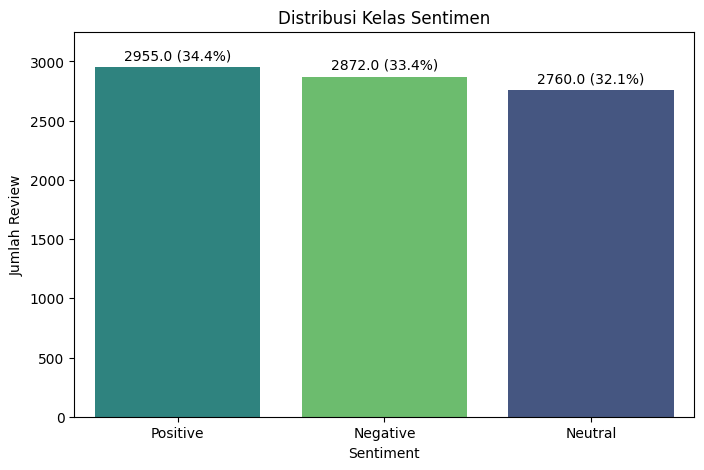

In [19]:
# Display distribusi kelas
plt.figure(figsize=(8, 5))
counts = df['Sentiment'].value_counts()
total = len(df)

ax = sns.countplot(
    data=df,
    x='Sentiment',
    hue='Sentiment',
    palette='viridis',
    order=counts.index,
    legend=False
)

for container in ax.containers:
    labels = [f'{v.get_height()} ({v.get_height()/total:.1%})' for v in container]
    ax.bar_label(container, labels=labels, padding=3)

plt.title('Distribusi Kelas Sentimen')
plt.ylabel('Jumlah Review')
plt.ylim(0, counts.max() * 1.1)
plt.show()

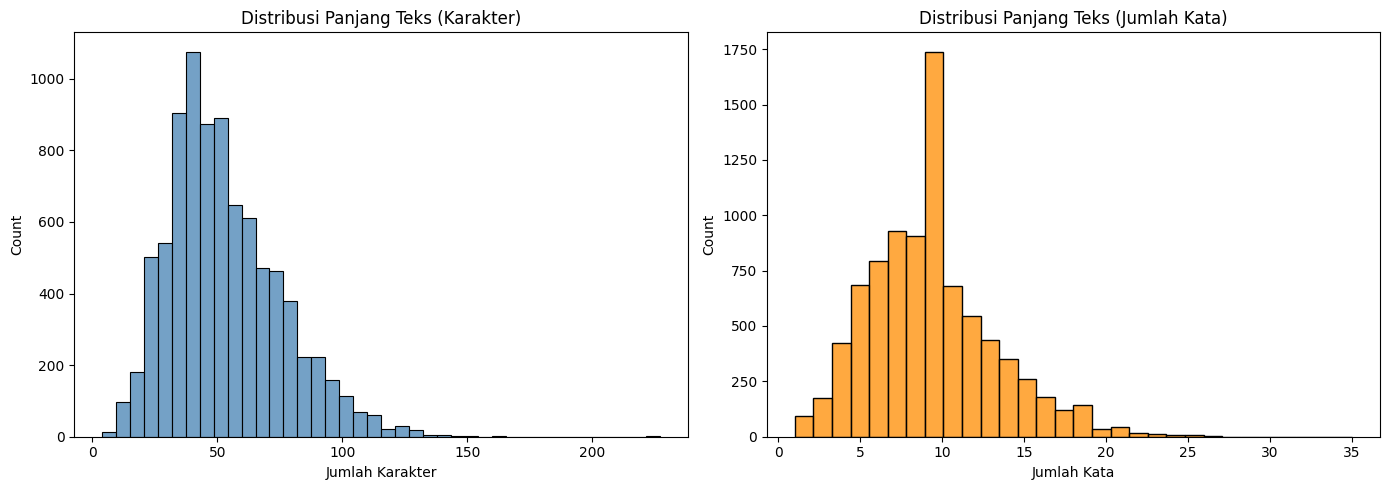

In [20]:
# Display distribusi panjang karakter dan kata dalam review
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['char_length'], bins=40, ax=axes[0], color='steelblue')
axes[0].set_title('Distribusi Panjang Teks (Karakter)')
axes[0].set_xlabel('Jumlah Karakter')

sns.histplot(df['word_count'], bins=30, ax=axes[1], color='darkorange')
axes[1].set_title('Distribusi Panjang Teks (Jumlah Kata)')
axes[1].set_xlabel('Jumlah Kata')

plt.tight_layout()
plt.show()

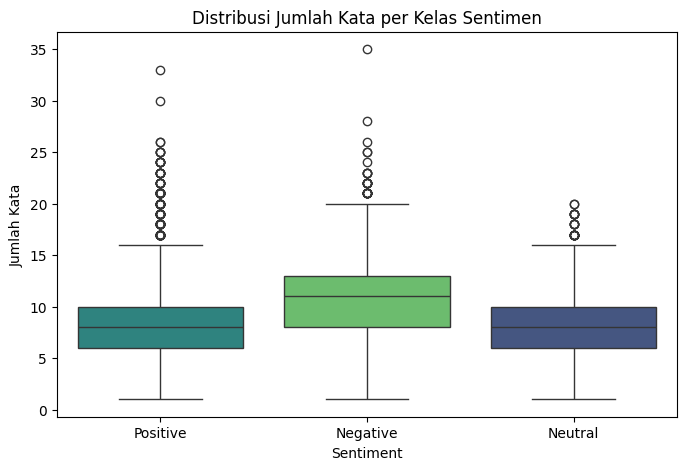

            count       mean       std  min  25%   50%   75%   max
Sentiment                                                         
Negative   2872.0  10.777159  3.844748  1.0  8.0  11.0  13.0  35.0
Neutral    2760.0   8.217391  3.069543  1.0  6.0   8.0  10.0  20.0
Positive   2955.0   8.809814  4.107687  1.0  6.0   8.0  10.0  33.0


In [21]:
# Display outlier per sentimen berdasarkan jumlah kata
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Sentiment', y='word_count', hue='Sentiment',
            order=df['Sentiment'].value_counts().index, palette='viridis', legend=False)
plt.title('Distribusi Jumlah Kata per Kelas Sentimen')
plt.ylabel('Jumlah Kata')
plt.show()

print(df.groupby('Sentiment')['word_count'].describe())

In [22]:
# Display kata unik per sentimen
from sklearn.feature_extraction.text import CountVectorizer

texts_by_class = {
    s: df[df['Sentiment'] == s]['text'].astype(str)
    for s in df['Sentiment'].unique()
}

vocabs = {}
for s, texts in texts_by_class.items():
    cv = CountVectorizer(stop_words='english', lowercase=True)
    cv.fit(texts)
    vocabs[s] = set(cv.vocabulary_.keys())
    print(f"{s}: {len(vocabs[s])} unique words")

Neutral: 2491 unique words
Positive: 2498 unique words
Negative: 3613 unique words


In [23]:
# Cari jaccard similarity antar sentimen
classes = list(vocabs.keys())
for i in range(len(classes)):
    for j in range(i + 1, len(classes)):
        a, b = classes[i], classes[j]
        inter = vocabs[a] & vocabs[b]
        union = vocabs[a] | vocabs[b]
        jaccard = len(inter) / len(union)
        print(f"{a} vs {b}: shared words = {len(inter)}, jaccard similarity = {jaccard:.3f}")

Neutral vs Positive: shared words = 1244, jaccard similarity = 0.332
Neutral vs Negative: shared words = 1420, jaccard similarity = 0.303
Positive vs Negative: shared words = 1283, jaccard similarity = 0.266


In [24]:
# Display top 15 words yang paling banyak muncul per sentimen
for s, texts in texts_by_class.items():
    cv = CountVectorizer(stop_words='english', lowercase=True)
    X = cv.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = cv.get_feature_names_out()

    other_vocab = set()
    for s2 in classes:
        if s2 != s:
            other_vocab |= vocabs[s2]

    unique_words = [(vocab[i], int(freqs[i])) for i in range(len(vocab)) if vocab[i] not in other_vocab]
    unique_words.sort(key=lambda x: -x[1])

    print(f"--- Words unique to '{s}' (top 15) ---")
    print(unique_words[:15])
    print()

--- Words unique to 'Neutral' (top 15) ---
[('fertilizer', 63), ('yield', 52), ('measures', 17), ('fashion', 11), ('yields', 11), ('okay', 10), ('land', 7), ('socks', 7), ('sweetness', 7), ('wine', 7), ('attraction', 6), ('check', 6), ('crop', 6), ('fertilizers', 6), ('jbl', 6)]

--- Words unique to 'Positive' (top 15) ---
[('pillows', 31), ('girl', 29), ('honey', 26), ('bookshelf', 23), ('bookcase', 21), ('ac', 17), ('daughter', 17), ('thanks', 15), ('biscuits', 13), ('boy', 13), ('atmosphere', 12), ('maintains', 12), ('wonderful', 11), ('bedsheet', 10), ('chairs', 10)]

--- Words unique to 'Negative' (top 15) ---
[('causing', 117), ('resulting', 92), ('poorly', 69), ('leaving', 52), ('bath', 39), ('residue', 39), ('inadequate', 29), ('dull', 28), ('frustrating', 27), ('fails', 26), ('requiring', 26), ('stale', 24), ('strange', 23), ('caused', 22), ('confusing', 20)]



In [25]:
# Bikin fungsi untuk display top 10 n-gram
def get_top_tfidf_ngrams(corpus, n=10, n_gram_range=(2,2)):
    tfidf = TfidfVectorizer(ngram_range=n_gram_range, stop_words='english')

    tfidf_matrix = tfidf.fit_transform(corpus)

    mean_tfidf_scores = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

    feature_names = tfidf.get_feature_names_out()
    tfidf_dict = dict(zip(feature_names, mean_tfidf_scores))

    sorted_tfidf = sorted(tfidf_dict.items(), key=lambda x: x[1], reverse=True)
    return sorted_tfidf[:n]

In [26]:
# Memisahkan sentimen negatif, positif, dan neutral
negative_reviews = df[df['Sentiment'] == 'Negative']['text']
positive_reviews = df[df['Sentiment'] == 'Positive']['text']
neutral_reviews = df[df['Sentiment'] == 'Neutral']['text']

/tmp/ipykernel_3400/2855017597.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=neg_df, x='Skor TF-IDF Rata-rata', y='N-Gram', palette='Reds_r')


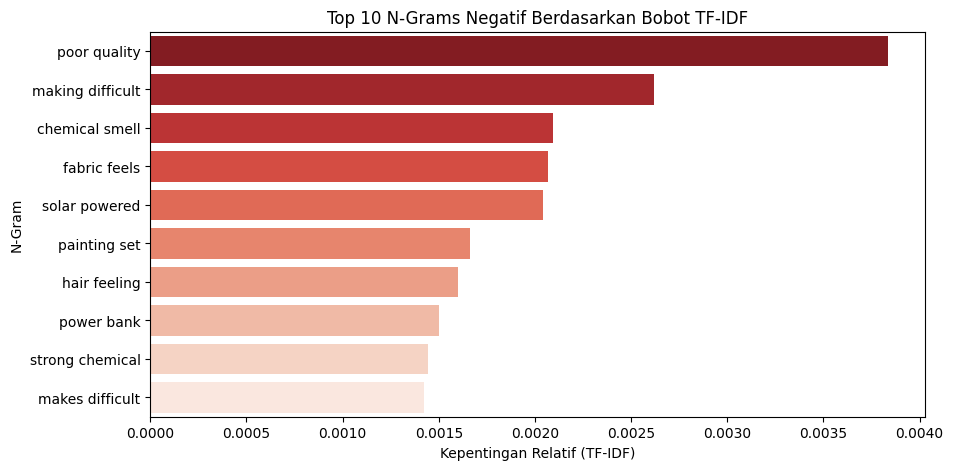

In [27]:
# Display top 10 bigram atau trigram review negatif
top_neg_tfidf = get_top_tfidf_ngrams(negative_reviews, n=10, n_gram_range=(2,3)) # Cek Bigram & Trigram
if top_neg_tfidf:
    neg_df = pd.DataFrame(top_neg_tfidf, columns=['N-Gram', 'Skor TF-IDF Rata-rata'])
    plt.figure(figsize=(10, 5))
    sns.barplot(data=neg_df, x='Skor TF-IDF Rata-rata', y='N-Gram', palette='Reds_r')
    plt.title('Top 10 N-Grams Negatif Berdasarkan Bobot TF-IDF')
    plt.xlabel('Kepentingan Relatif (TF-IDF)')
    plt.show()

/tmp/ipykernel_3400/2337981126.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pos_df, x='Skor TF-IDF Rata-rata', y='N-Gram', palette='Greens_r')


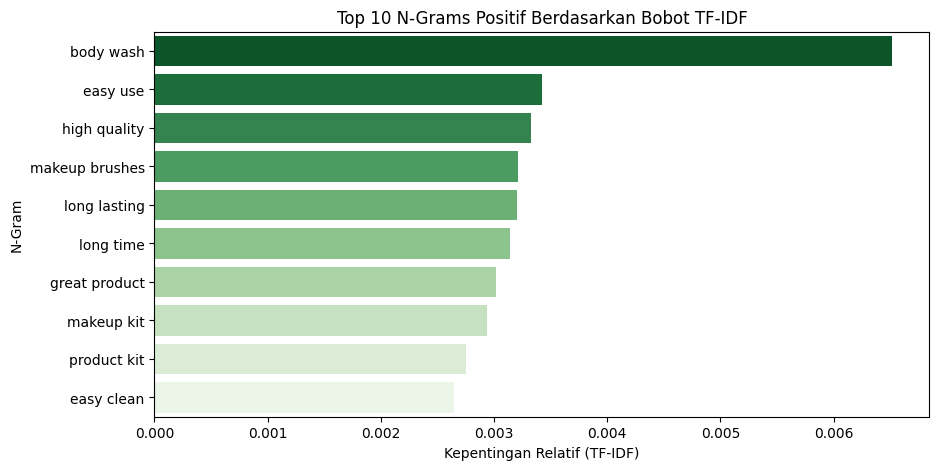

In [28]:
# Display top 10 bigram atau trigram review positif
top_pos_tfidf = get_top_tfidf_ngrams(positive_reviews, n=10, n_gram_range=(2,3))
if top_pos_tfidf:
    pos_df = pd.DataFrame(top_pos_tfidf, columns=['N-Gram', 'Skor TF-IDF Rata-rata'])
    plt.figure(figsize=(10, 5))
    sns.barplot(data=pos_df, x='Skor TF-IDF Rata-rata', y='N-Gram', palette='Greens_r')
    plt.title('Top 10 N-Grams Positif Berdasarkan Bobot TF-IDF')
    plt.xlabel('Kepentingan Relatif (TF-IDF)')
    plt.show()

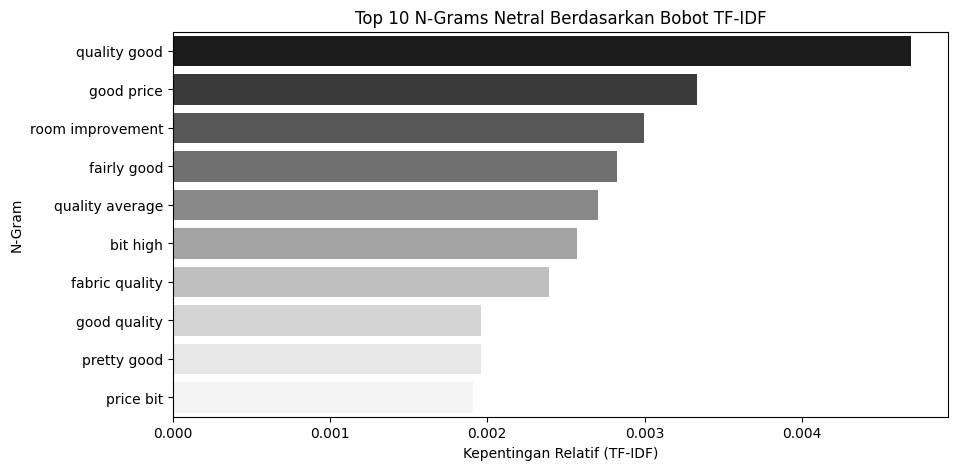

In [29]:
# Display top 10 bigram atau trigram review neutral
top_neu_tfidf = get_top_tfidf_ngrams(neutral_reviews, n=10, n_gram_range=(2,3))
if top_neu_tfidf:
    neu_df = pd.DataFrame(top_neu_tfidf, columns=['N-Gram', 'Skor TF-IDF Rata-rata'])
    plt.figure(figsize=(10, 5))
    sns.barplot(data=neu_df, x='Skor TF-IDF Rata-rata', y='N-Gram', hue='N-Gram', palette='Greys_r', legend=False)
    plt.title('Top 10 N-Grams Netral Berdasarkan Bobot TF-IDF')
    plt.xlabel('Kepentingan Relatif (TF-IDF)')
    plt.show()

# PREPROCESSING

In [30]:
# Bikin function untuk clean text basic untuk semua model
def clean_text_base(text):
  # Bikin text jadi string
  text = str(text)
  # Ganti karakter non-ASCII yang tadi ditemukan dengan spasi
  text = text.replace('\u200b', ' ')
  # Ubah text jadi huruf kecil
  text = text.lower()
  # Hapus link
  text = re.sub(r'http\S+|www\.\S+', '', text)
  # Hapus angka
  text = re.sub(r'\d+', '', text)
  # Hapus tanda baca dan karakter non-huruf
  text = re.sub(r'[^\w\s]', '', text)
  # Hapus _ yang tidak termasuk dalam \w
  text = re.sub(r'_', '', text)
  # Hapus spasi berlebihan
  text = re.sub(r'\s+', ' ', text).strip()
  return text

df['text_clean_base'] = df['text'].apply(clean_text_base)

# Pastikan tidak ada lagi non-ASCII
has_nonascii = df['text_clean_base'].apply(lambda x: bool(re.search(r'[^\x00-\x7F]', x)))
print(f'Baris masih mengandung non-ASCII setelah cleaning: {has_nonascii.sum()}')

# Cek teks yang jadi kosong setelah cleaning
empty_after = df['text_clean_base'].str.strip().eq('').sum()
print(f'Teks jadi kosong setelah cleaning: {empty_after}')

print('\nContoh hasil cleaning:')
df[['text', 'text_clean_base']].head(5)

Baris masih mengandung non-ASCII setelah cleaning: 0
Teks jadi kosong setelah cleaning: 0

Contoh hasil cleaning:


,text,text_clean_base
0,Great but disappointingly small,great but disappointingly small
1,The design is very fashionable,the design is very fashionable
2,was poorly roasted resulting in uneven flavor...,was poorly roasted resulting in uneven flavor ...
3,Suitable for the whole family,suitable for the whole family
4,The set pieces were poorly painted with smudg...,the set pieces were poorly painted with smudge...


In [31]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Bikin function untuk clean text untuk model Naive Bayes, Logistic Regression, dan XGBoost
def clean_text_classical(text):
    text = clean_text_base(text)
    tokens = word_tokenize(text)
    # Hapus stopword
    tokens = [t for t in tokens if t not in stop_words]
    # Stemming
    tokens = [stemmer.stem(t) for t in tokens]
    # Hapus token terlalu pendek (1 karakter)
    tokens = [t for t in tokens if len(t) > 1]
    return ' '.join(tokens)

df['text_classical'] = df['text'].apply(clean_text_classical)

print('Contoh perbandingan:')
df[['text', 'text_clean_base', 'text_classical']].head(8)

Contoh perbandingan:


,text,text_clean_base,text_classical
0,Great but disappointingly small,great but disappointingly small,great disappointingli small
1,The design is very fashionable,the design is very fashionable,design fashion
2,was poorly roasted resulting in uneven flavor...,was poorly roasted resulting in uneven flavor ...,poorli roast result uneven flavor develop
3,Suitable for the whole family,suitable for the whole family,suitabl whole famili
4,The set pieces were poorly painted with smudg...,the set pieces were poorly painted with smudge...,set piec poorli paint smudg stain
5,Playdo is dry and cannot be used,playdo is dry and cannot be used,playdo dri use
6,No smell which is good,no smell which is good,smell good
7,There should be sufficient number of pads in t...,there should be sufficient number of pads in t...,suffici number pad packet


In [32]:
# Cek text yang menjadi kosong akibat classical cleaning
empty_classical = df['text_classical'].str.strip().eq('')
print(f'Teks kosong setelah classical cleaning: {empty_classical.sum()}')
if empty_classical.sum() > 0:
    print('Contoh:')
    display(df[empty_classical][['text', 'text_classical', 'label']].head())

Teks kosong setelah classical cleaning: 0


In [33]:
# Label encoding untuk mengubah sentimen menjadi integer
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Sentiment'])

print('Mapping label:')
for i, cls in enumerate(le.classes_):
    print(f'  {cls} -> {i}')

print(f'\nDistribusi label encoded:')
print(df['label_encoded'].value_counts().sort_index())

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print('\nLabelEncoder disimpan ke label_encoder.pkl')

Mapping label:
  Negative -> 0
  Neutral -> 1
  Positive -> 2

Distribusi label encoded:
label_encoded
0    2872
1    2760
2    2955
Name: count, dtype: int64

LabelEncoder disimpan ke label_encoder.pkl


In [34]:
# Untuk LR, NB, XGBoost
X = df['text_classical']
# Untuk BERT
X_bert = df['text_clean_base']
y = df['label_encoded']

# Split 80% train, 20% temp untuk di split lagi jadi 10% val, 10% test
X_train, X_temp, X_bert_train, X_bert_temp, y_train, y_temp = train_test_split(
    X, X_bert, y, test_size=0.2, random_state=42, stratify=y
)

# Split temp 50/50, masing-masing val dan test 10%
X_val, X_test, X_bert_val, X_bert_test, y_val, y_test = train_test_split(
    X_temp, X_bert_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Train : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Val   : {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')

print('\nDistribusi kelas di Train:')
print(pd.Series(y_train).value_counts().sort_index().to_string())
print('\nDistribusi kelas di Val:')
print(pd.Series(y_val).value_counts().sort_index().to_string())
print('\nDistribusi kelas di Test:')
print(pd.Series(y_test).value_counts().sort_index().to_string())

Train : 6,869 (80.0%)
Val   : 859 (10.0%)
Test  : 859 (10.0%)

Distribusi kelas di Train:
label_encoded
0    2297
1    2208
2    2364

Distribusi kelas di Val:
label_encoded
0    287
1    276
2    296

Distribusi kelas di Test:
label_encoded
0    288
1    276
2    295


In [35]:
# Gunakan Tfidf untuk Naive Bayes, Logistic Regression, XGBoost
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Shape TF-IDF train : {X_train_tfidf.shape}')
print(f'Shape TF-IDF val   : {X_val_tfidf.shape}')
print(f'Shape TF-IDF test  : {X_test_tfidf.shape}')

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print('\nTF-IDF Vectorizer disimpan ke tfidf_vectorizer.pkl')

Shape TF-IDF train : (6869, 6384)
Shape TF-IDF val   : (859, 6384)
Shape TF-IDF test  : (859, 6384)

TF-IDF Vectorizer disimpan ke tfidf_vectorizer.pkl


In [36]:
CLASS_NAMES = list(le.classes_)  # ['Negative', 'Neutral', 'Positive']

# Bikin variabel untuk menyimpan hasil model
results_summary = {}

# Bikin fungsi untuk evaluasi model
def evaluate_model(name, y_true, y_pred, class_names=CLASS_NAMES):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f'{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  Macro F1   : {macro_f1:.4f}')
    print()
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names
    )
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

    results_summary[name] = {'Accuracy': acc, 'Macro F1': macro_f1}
    return

── Hyperparameter Tuning ──
Best Parameters: {'C': 10, 'penalty': 'l2'}

── Validation ──
  Logistic Regression (Val)
  Accuracy   : 0.8417
  Macro F1   : 0.8401

              precision    recall  f1-score   support

    Negative       0.89      0.90      0.89       287
     Neutral       0.81      0.76      0.78       276
    Positive       0.82      0.87      0.85       296

    accuracy                           0.84       859
   macro avg       0.84      0.84      0.84       859
weighted avg       0.84      0.84      0.84       859



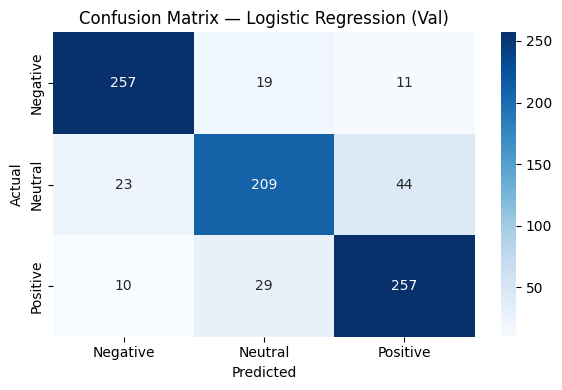

In [44]:
from sklearn.model_selection import GridSearchCV

# Inisialisasi model Logistic Regression
base_lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# Inisialisasi parameter grid search
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}

# Hyperparamter tuning menggunakan GridSearch
print('── Hyperparameter Tuning ──')
grid_search = GridSearchCV(base_lr, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

# Simpan model terbaik
lr_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Evaluasi model hasil tuning dengan validation
print('\n── Validation ──')
lr_val_pred = lr_model.predict(X_val_tfidf)
evaluate_model('Logistic Regression (Val)', y_val, lr_val_pred)

── Test Set ──
  Logistic Regression (Test)
  Accuracy   : 0.8219
  Macro F1   : 0.8194

              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86       288
     Neutral       0.79      0.72      0.75       276
    Positive       0.81      0.87      0.84       295

    accuracy                           0.82       859
   macro avg       0.82      0.82      0.82       859
weighted avg       0.82      0.82      0.82       859



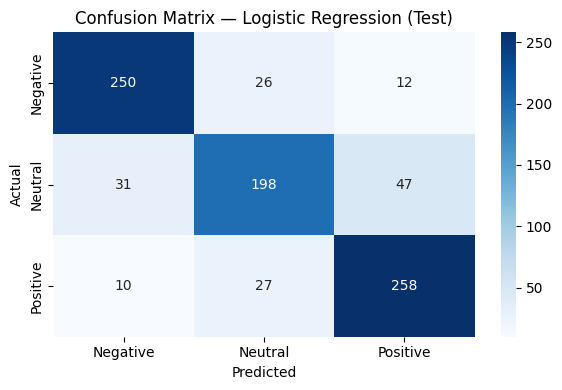

Model disimpan ke lr_model.pkl


In [45]:
# Evaluasi model Logistic Regression ke test set
print('── Test Set ──')
lr_test_pred = lr_model.predict(X_test_tfidf)
evaluate_model('Logistic Regression (Test)', y_test, lr_test_pred)

with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print('Model disimpan ke lr_model.pkl')

── Hyperparameter Tuning ──
Best Parameters: {'alpha': 0.5}

── Validation ──
  Naive Bayes (Val)
  Accuracy   : 0.8370
  Macro F1   : 0.8349

              precision    recall  f1-score   support

    Negative       0.87      0.90      0.88       287
     Neutral       0.80      0.74      0.77       276
    Positive       0.83      0.87      0.85       296

    accuracy                           0.84       859
   macro avg       0.84      0.84      0.83       859
weighted avg       0.84      0.84      0.84       859



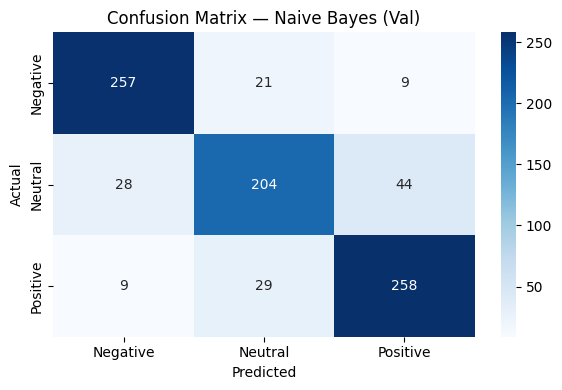

In [46]:
# Inisialisasi model Naive Bayes
base_nb = MultinomialNB()

# Inisialisasi parameter grid search
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 2.0]
}

# Hyperparameter tuning menggunakan GridSearch
print('── Hyperparameter Tuning ──')
grid_search = GridSearchCV(base_nb, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

# Simpan model terbaik
nb_model = grid_search.best_estimator_
print(f'Best Parameters: {grid_search.best_params_}')

# Evaluasi model hasil tuning dengan validation
print('\n── Validation ──')
nb_val_pred = nb_model.predict(X_val_tfidf)
evaluate_model('Naive Bayes (Val)', y_val, nb_val_pred)

── Test Set ──
  Naive Bayes (Test)
  Accuracy   : 0.8196
  Macro F1   : 0.8172

              precision    recall  f1-score   support

    Negative       0.85      0.87      0.86       288
     Neutral       0.77      0.72      0.74       276
    Positive       0.83      0.86      0.85       295

    accuracy                           0.82       859
   macro avg       0.82      0.82      0.82       859
weighted avg       0.82      0.82      0.82       859



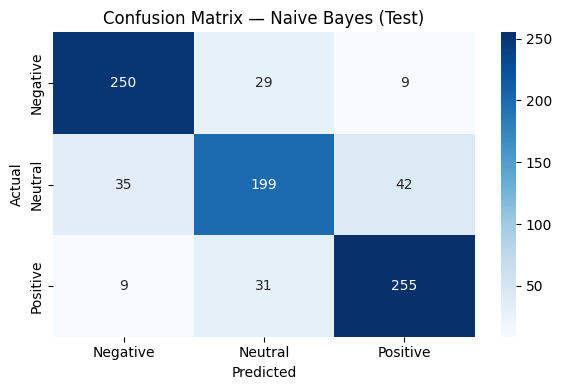

Model disimpan ke nb_model.pkl


In [47]:
# Evaluasi model Naive Bayes ke test set
print('── Test Set ──')
nb_test_pred = nb_model.predict(X_test_tfidf)
evaluate_model('Naive Bayes (Test)', y_test, nb_test_pred)

with open('nb_model.pkl', 'wb') as f:
    pickle.dump(nb_model, f)
print('Model disimpan ke nb_model.pkl')

In [48]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

# Inisialisasi base model
base_xgb = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    tree_method='hist',
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

# Inisialisasi parameter untuk RandomizedSearch
param_dist = {
    'n_estimators': [200, 500],
    'max_depth': [3, 4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.5]
}

# Hyperparameter tuning menggunakan Randomized Search
print('── Hyperparameter Tuning (Randomized Search) ──')
random_search = RandomizedSearchCV(
    base_xgb, param_dist, n_iter=30, cv=5,
    scoring='f1_macro', n_jobs=-1, random_state=42
)
random_search.fit(X_train_tfidf, y_train)

best_params = random_search.best_params_
print('Best Parameters:', best_params)

# Fit dengan early stopping dan parameter terbaik
xgb_model = xgb.XGBClassifier(
    **best_params,
    objective='multi:softmax',
    num_class=3,
    tree_method='hist',
    eval_metric='mlogloss',
    early_stopping_rounds=20,
    random_state=42,
    verbosity=0
)

xgb_model.fit(
    X_train_tfidf, y_train,
    eval_set=[(X_val_tfidf, y_val)],
    verbose=50
)

print(f'\nBest iteration: {xgb_model.best_iteration}')

── Hyperparameter Tuning (Randomized Search) ──
Best Parameters: {'subsample': 1.0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.6}
[0]	validation_0-mlogloss:1.08056
[50]	validation_0-mlogloss:0.77684
[100]	validation_0-mlogloss:0.67953
[150]	validation_0-mlogloss:0.62379
[200]	validation_0-mlogloss:0.58823
[250]	validation_0-mlogloss:0.56057
[300]	validation_0-mlogloss:0.54094
[350]	validation_0-mlogloss:0.52504
[400]	validation_0-mlogloss:0.51169
[450]	validation_0-mlogloss:0.50250
[499]	validation_0-mlogloss:0.49429

Best iteration: 499


── Test Set ──
  XGBoost (Test)
  Accuracy   : 0.7893
  Macro F1   : 0.7896

              precision    recall  f1-score   support

    Negative       0.90      0.80      0.85       288
     Neutral       0.72      0.74      0.73       276
    Positive       0.76      0.83      0.80       295

    accuracy                           0.79       859
   macro avg       0.79      0.79      0.79       859
weighted avg       0.79      0.79      0.79       859



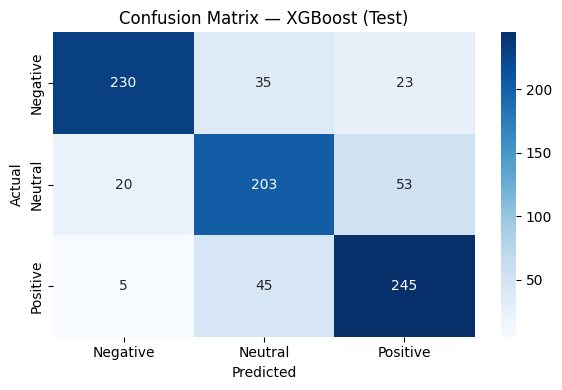

Model disimpan ke xgb_model.json


In [49]:
# Evaluasi model XGBoost ke test set
print('── Test Set ──')
xgb_test_pred = xgb_model.predict(X_test_tfidf)
evaluate_model('XGBoost (Test)', y_test, xgb_test_pred)

xgb_model.save_model('xgb_model.json')
print('Model disimpan ke xgb_model.json')

/tmp/ipykernel_3400/17847900.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')


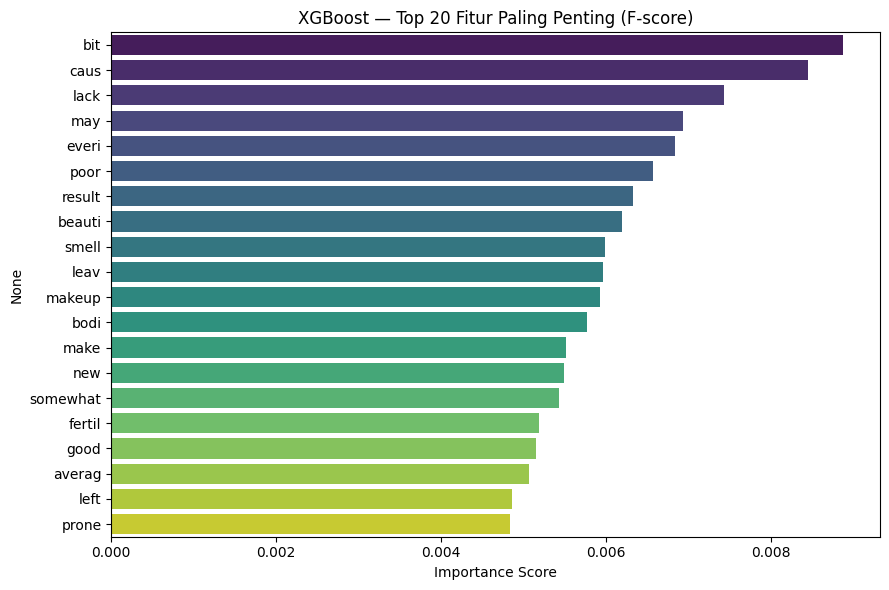

In [50]:
# Display top 20 important features untuk XGBoost
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=tfidf.get_feature_names_out()
).nlargest(20)

plt.figure(figsize=(9, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title('XGBoost — Top 20 Fitur Paling Penting (F-score)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [37]:
# Persiapan train model BERT
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizerFast, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN  = 48
BATCH    = 16
EPOCHS   = 4
LR       = 2e-5

print(f'Device: {DEVICE}')

tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            list(texts), max_length=max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

train_ds = SentimentDataset(X_bert_train.reset_index(drop=True), y_train.reset_index(drop=True), tokenizer, MAX_LEN)
val_ds   = SentimentDataset(X_bert_val.reset_index(drop=True),   y_val.reset_index(drop=True),   tokenizer, MAX_LEN)
test_ds  = SentimentDataset(X_bert_test.reset_index(drop=True),  y_test.reset_index(drop=True),  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32,    shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32,    shuffle=False)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Device: cuda


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train batches: 430 | Val: 27 | Test: 27


In [38]:
# Inisialisasi model BERT
bert_model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', num_labels=3
).to(DEVICE)

optimizer = AdamW(bert_model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

print(f'Total training steps : {total_steps}')
print(f'Warmup steps         : {int(0.1*total_steps)}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total training steps : 1720
Warmup steps         : 172


In [39]:
# Bikin fungsi untuk train dan evaluasi epoch BERT
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct = 0, 0
    for batch in loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == batch['labels']).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)

def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=1)
            correct += (preds == batch['labels']).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
    return total_loss / len(loader), correct / len(loader.dataset), all_preds, all_labels

In [40]:
# Train model BERT
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
best_val_acc = 0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(bert_model, train_loader, optimizer, scheduler, DEVICE)
    vl_loss, vl_acc, _, _ = eval_epoch(bert_model, val_loader, DEVICE)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch}/{EPOCHS} '
          f'| Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} '
          f'| Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        bert_model.save_pretrained('bert_best')
        tokenizer.save_pretrained('bert_best')
        print(f'Model terbaik disimpan (val acc: {best_val_acc:.4f})')

print(f'\nTraining selesai. Best val accuracy: {best_val_acc:.4f}')

Epoch 1/4 | Train Loss: 0.5069  Acc: 0.7866 | Val Loss: 0.2646  Acc: 0.9127


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model terbaik disimpan (val acc: 0.9127)
Epoch 2/4 | Train Loss: 0.1769  Acc: 0.9495 | Val Loss: 0.2649  Acc: 0.9185


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model terbaik disimpan (val acc: 0.9185)
Epoch 3/4 | Train Loss: 0.0897  Acc: 0.9766 | Val Loss: 0.3482  Acc: 0.9220


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model terbaik disimpan (val acc: 0.9220)
Epoch 4/4 | Train Loss: 0.0526  Acc: 0.9882 | Val Loss: 0.3717  Acc: 0.9290


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model terbaik disimpan (val acc: 0.9290)

Training selesai. Best val accuracy: 0.9290


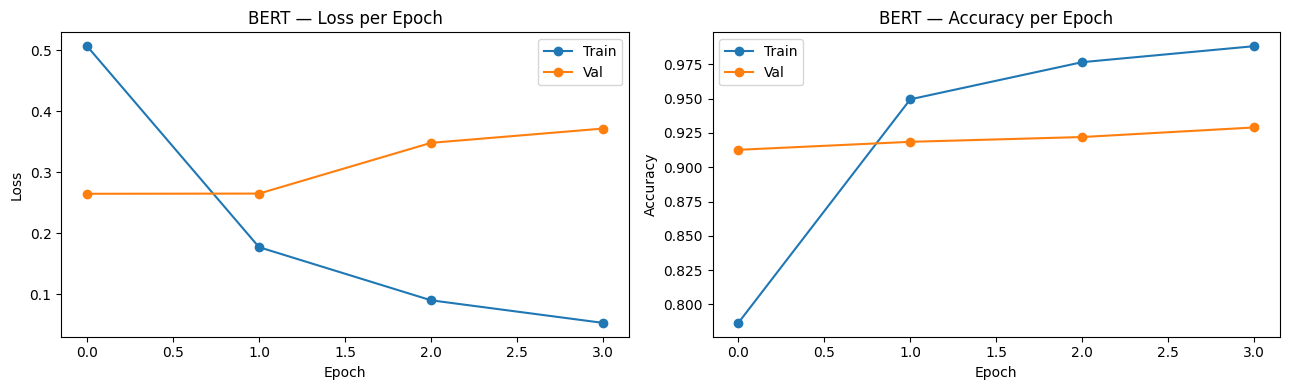

In [41]:
# Display loss dan accuracy per epoch
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['val_loss'],   label='Val',   marker='o')
axes[0].set_title('BERT — Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train', marker='o')
axes[1].plot(history['val_acc'],   label='Val',   marker='o')
axes[1].set_title('BERT — Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

── Test Set ──
  BERT (Test)
  Accuracy   : 0.9441
  Macro F1   : 0.9437

              precision    recall  f1-score   support

    Negative       0.97      0.94      0.95       288
     Neutral       0.94      0.91      0.93       276
    Positive       0.92      0.98      0.95       295

    accuracy                           0.94       859
   macro avg       0.94      0.94      0.94       859
weighted avg       0.94      0.94      0.94       859



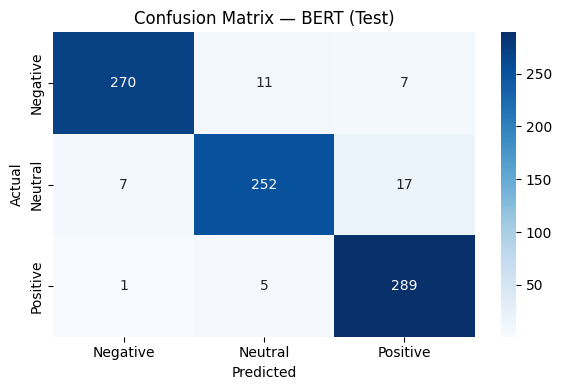

In [51]:
# Evaluasi model BERT ke test set
from transformers import BertForSequenceClassification as BertCls

best_bert = BertCls.from_pretrained('bert_best').to(DEVICE)
_, _, bert_test_pred, bert_test_true = eval_epoch(best_bert, test_loader, DEVICE)

print('── Test Set ──')
evaluate_model('BERT (Test)', bert_test_true, bert_test_pred)

In [60]:
# Kumpulkan semua prediksi test set
all_preds = {
    'Logistic Regression': lr_test_pred,
    'Naive Bayes':         nb_test_pred,
    'XGBoost':             xgb_test_pred,
    'BERT':                np.array(bert_test_pred),
}
y_true_classical = y_test.values
y_true_bert      = np.array(bert_test_true)

# Display tabel perbandingan
rows = []
for name, preds in all_preds.items():
    y_true = y_true_bert if name == 'BERT' else y_true_classical
    rows.append({
        'Model'     : name,
        'Accuracy'  : accuracy_score(y_true, preds),
        'Macro F1'  : f1_score(y_true, preds, average='macro'),
        'Weighted F1': f1_score(y_true, preds, average='weighted'),
    })

comparison_df = pd.DataFrame(rows).set_index('Model').round(4)
print('Perbandingan Performa di Test Set')
display(comparison_df.sort_values('Macro F1', ascending=False))

Perbandingan Performa di Test Set


,Accuracy,Macro F1,Weighted F1
Model,,,
BERT,0.9441,0.9437,0.9440
Logistic Regression,0.8219,0.8194,0.8205
Naive Bayes,0.8196,0.8172,0.8185
XGBoost,0.7893,0.7896,0.7906


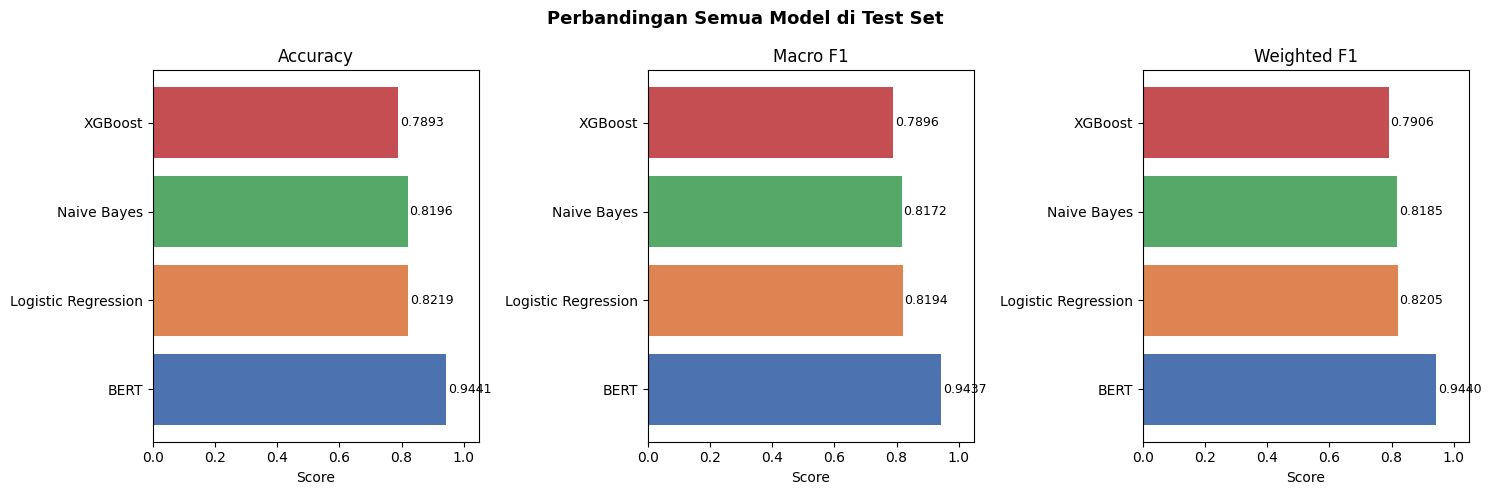

In [53]:
# Bar chart perbandingan semua model di test set
comp = comparison_df.sort_values('Macro F1', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['Accuracy', 'Macro F1', 'Weighted F1']
colors  = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

for ax, metric in zip(axes, metrics):
    bars = ax.barh(comp.index, comp[metric], color=colors[:len(comp)])
    ax.set_xlim(0, 1.05)
    ax.set_title(metric)
    ax.set_xlabel('Score')
    for bar, val in zip(bars, comp[metric]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Perbandingan Semua Model di Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

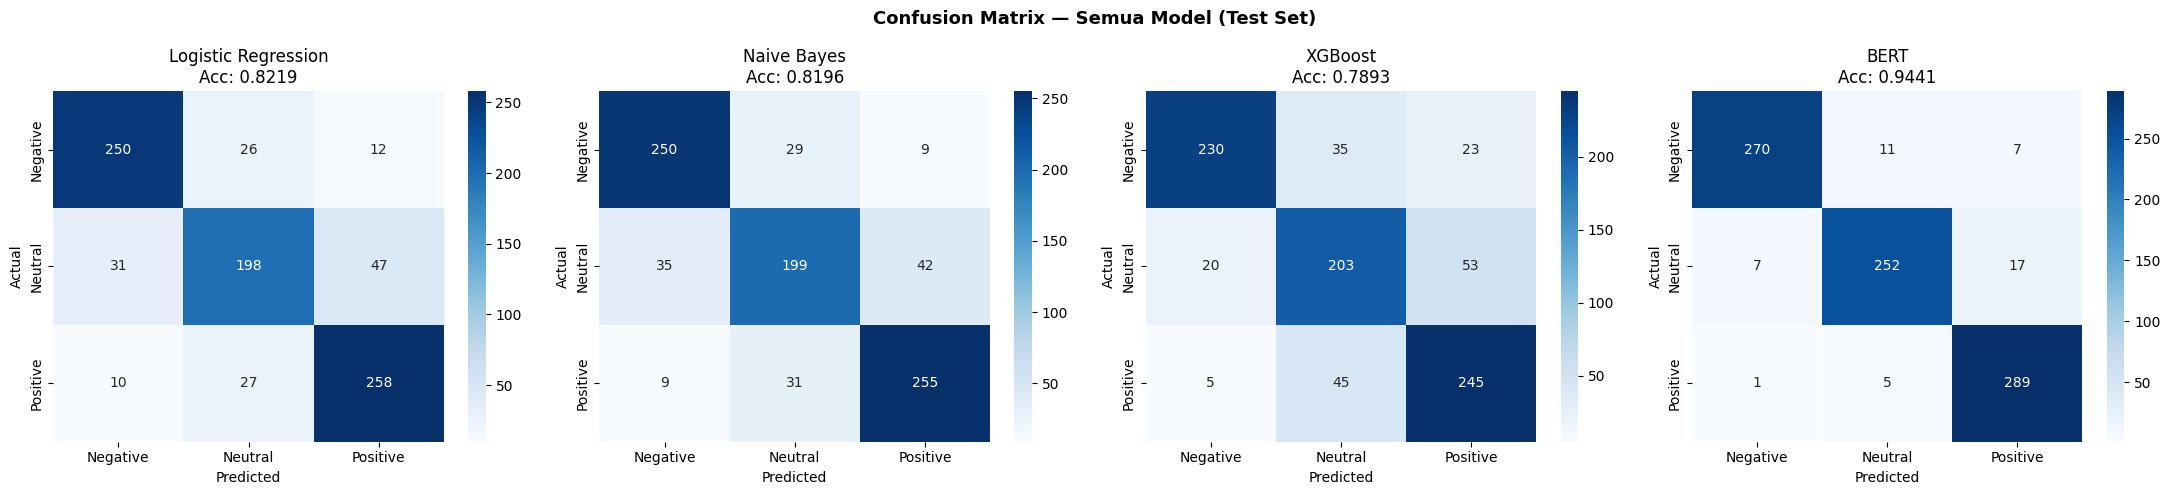

In [54]:
# Confusion matrix semua model
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
model_preds = [
    ('Logistic Regression', y_true_classical, lr_test_pred),
    ('Naive Bayes',         y_true_classical, nb_test_pred),
    ('XGBoost',             y_true_classical, xgb_test_pred),
    ('BERT',                y_true_bert,      np.array(bert_test_pred)),
]

for ax, (name, y_true, y_pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax
    )
    acc = accuracy_score(y_true, y_pred)
    ax.set_title(f'{name}\nAcc: {acc:.4f}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix — Semua Model (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

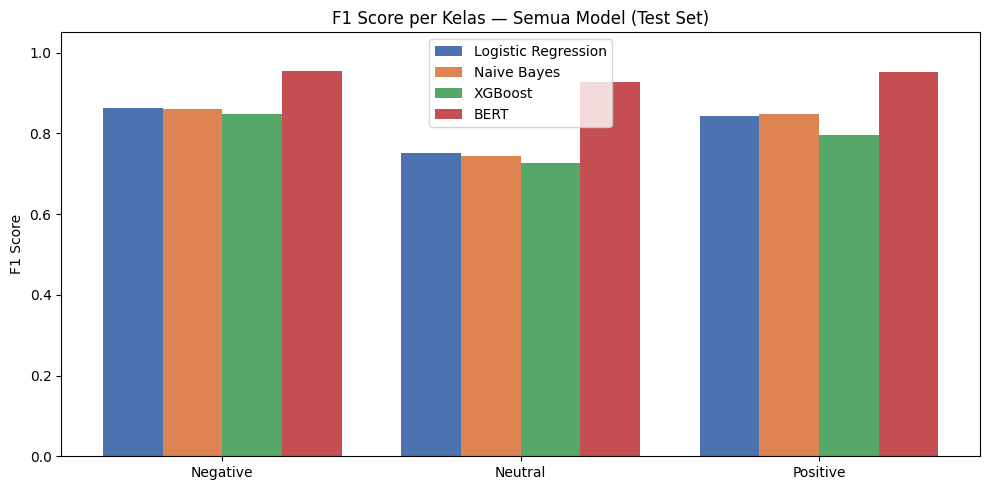

In [61]:
# F1 score tiap model
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(CLASS_NAMES))
width = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

for (name, y_true, y_pred), offset, color in zip(model_preds, offsets, colors):
    per_class_f1 = f1_score(y_true, y_pred, average=None)
    ax.bar(x + offset * width, per_class_f1, width, label=name, color=color)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1.05)
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score per Kelas — Semua Model (Test Set)')
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
# Ambil sampel teks yang diprediksi salah oleh semua model
test_df = pd.DataFrame({
    'text_original': X_bert_test.reset_index(drop=True),
    'true'         : le.inverse_transform(y_true_classical),
    'pred_lr'      : le.inverse_transform(lr_test_pred),
    'pred_nb'      : le.inverse_transform(nb_test_pred),
    'pred_xgb'     : le.inverse_transform(xgb_test_pred),
    'pred_bert'    : le.inverse_transform(bert_test_pred)
})

# Filter baris yang salah di keempat model sekaligus
all_wrong = test_df[
    (test_df['true'] != test_df['pred_lr']) &
    (test_df['true'] != test_df['pred_nb']) &
    (test_df['true'] != test_df['pred_xgb']) &
    (test_df['true'] != test_df['pred_bert'])
]

print(f'Sampel yang salah di semua model: {len(all_wrong)}')
display(all_wrong)

Sampel yang salah di semua model: 23


,text_original,true,pred_lr,pred_nb,pred_xgb,pred_bert
36,dji rc remote controller for dji air and dji m...,Negative,Positive,Positive,Positive,Positive
118,it becomes more of a decorative piece than a u...,Negative,Neutral,Neutral,Neutral,Neutral
196,will smooth easily,Neutral,Positive,Positive,Positive,Positive
204,the quality of the beads is average,Negative,Neutral,Neutral,Neutral,Neutral
268,of course there are simplistic negative points,Negative,Neutral,Neutral,Neutral,Neutral
291,buying gold is fun but expensive,Negative,Positive,Positive,Positive,Neutral
299,the travel essential has become anything but,Negative,Positive,Positive,Positive,Neutral
323,just what i wanted could be better quality,Negative,Neutral,Neutral,Neutral,Neutral
360,the fabric is not as expected,Negative,Neutral,Neutral,Neutral,Neutral
384,behind one of the best performances,Negative,Positive,Positive,Positive,Positive


In [62]:
def predict_all_models(text):
    # Preprocessing
    text_cl = clean_text_classical(text)
    text_be = clean_text_base(text)

    # TF-IDF transform
    vec = tfidf.transform([text_cl])

    # Prediksi klasikal
    pred_lr  = le.inverse_transform(lr_model.predict(vec))[0]
    pred_nb  = le.inverse_transform(nb_model.predict(vec))[0]
    pred_xgb = le.inverse_transform(xgb_model.predict(vec))[0]

    # Probabilitas klasikal
    proba_lr  = dict(zip(le.classes_, lr_model.predict_proba(vec)[0].round(3)))
    proba_nb  = dict(zip(le.classes_, nb_model.predict_proba(vec)[0].round(3)))
    proba_xgb = dict(zip(le.classes_, xgb_model.predict_proba(vec)[0].round(3)))

    # Prediksi BERT
    best_bert.eval()
    enc = tokenizer(
        [text_be], max_length=128,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        logits = best_bert(**enc).logits
    proba_bert_raw = torch.softmax(logits, dim=1).cpu().numpy()[0]
    pred_bert  = le.inverse_transform([proba_bert_raw.argmax()])[0]
    proba_bert = dict(zip(le.classes_, proba_bert_raw.round(3)))

    # Display hasil
    print(f'Input teks       : "{text}"')
    print(f'Setelah cleaning : "{text_cl}"')
    print()
    print(f'{'Model':<22} {'Prediksi':<12} {'Neg':>6} {'Neu':>6} {'Pos':>6}')
    print('-' * 55)
    for name, pred, proba in [
        ('Logistic Regression', pred_lr,  proba_lr),
        ('Naive Bayes',         pred_nb,  proba_nb),
        ('XGBoost',             pred_xgb, proba_xgb),
        ('BERT',                pred_bert,proba_bert),
    ]:
        neg = proba.get('Negative', 0)
        neu = proba.get('Neutral',  0)
        pos = proba.get('Positive', 0)
        print(f'{name:<22} {pred:<12} {neg:>6.3f} {neu:>6.3f} {pos:>6.3f}')

    # Bar chart probabilitas
    fig, axes = plt.subplots(1, 4, figsize=(16, 3), sharey=True)
    model_data = [
        ('Logistic Regression', proba_lr),
        ('Naive Bayes',         proba_nb),
        ('XGBoost',             proba_xgb),
        ('BERT',                proba_bert),
    ]
    bar_colors = {'Negative': '#e53935', 'Neutral': '#fb8c00', 'Positive': '#43a047'}
    for ax, (name, proba) in zip(axes, model_data):
        classes = list(proba.keys())
        values  = list(proba.values())
        colors  = [bar_colors[c] for c in classes]
        bars = ax.bar(classes, values, color=colors, edgecolor='white')
        ax.set_ylim(0, 1.05)
        ax.set_title(name, fontsize=9, fontweight='bold')
        ax.set_ylabel('Probabilitas' if ax == axes[0] else '')
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                    f'{val:.2f}', ha='center', fontsize=8)
    plt.suptitle(f'Distribusi Probabilitas Sentimen\n"{text[:60]}..."' if len(text) > 60
                 else f'Distribusi Probabilitas Sentimen\n"{text}"',
                 fontsize=10)
    plt.tight_layout()
    plt.show()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input #1
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input teks       : "Received in a few days. Fast delivery. Nice packing. Quality is very good. Thank you seller. Will purchase again."
Setelah cleaning : "receiv day fast deliveri nice pack qualiti good thank seller purchas"

Model                  Prediksi        Neg    Neu    Pos
-------------------------------------------------------
Logistic Regression    Positive      0.003  0.092  0.905
Naive Bayes            Positive      0.006  0.059  0.935
XGBoost                Positive      0.001  0.013  0.987
BERT                   Positive      0.001  0.000  0.998


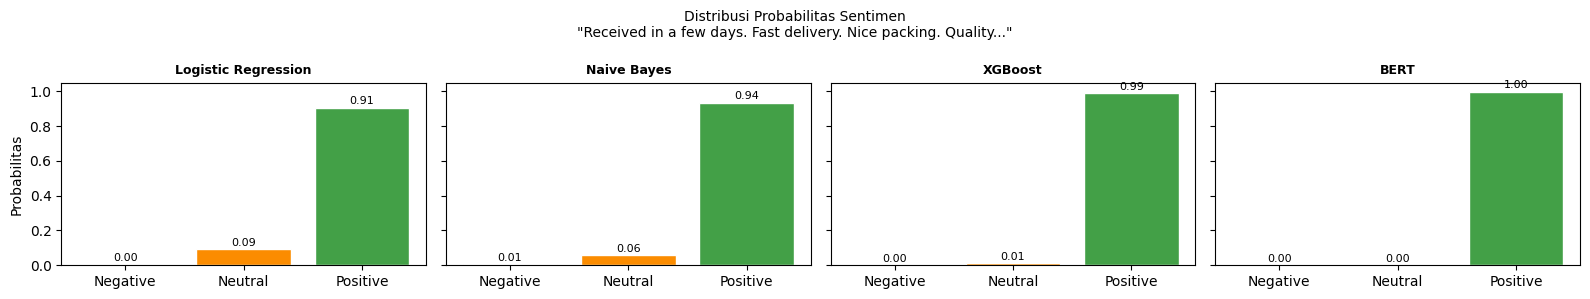


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input #2
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input teks       : "Good and nice to use . Package no Damages , will order again"
Setelah cleaning : "good nice use packag damag order"

Model                  Prediksi        Neg    Neu    Pos
-------------------------------------------------------
Logistic Regression    Neutral       0.006  0.510  0.484
Naive Bayes            Neutral       0.068  0.597  0.335
XGBoost                Positive      0.006  0.422  0.572
BERT                   Positive      0.001  0.000  0.998


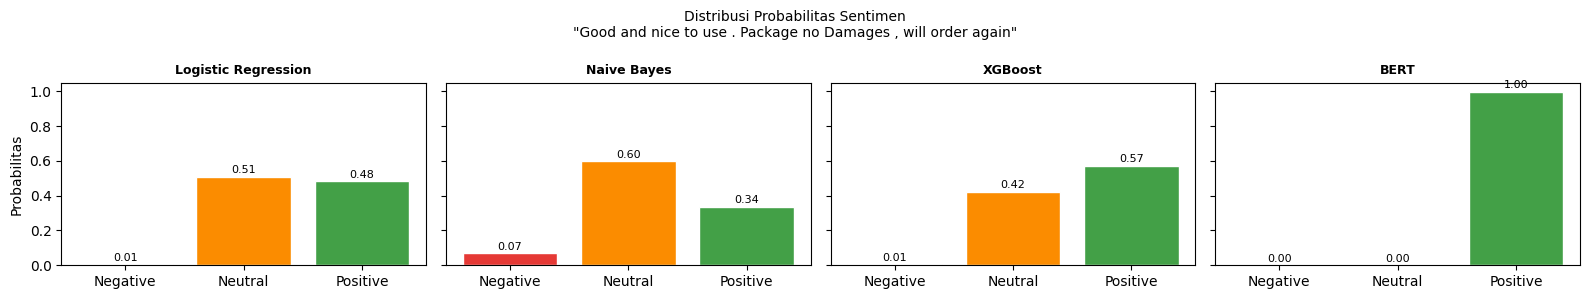


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input #3
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input teks       : "Reasonable material for the price BUT no QC, the surface that adhere to the phone surface have a little rough protruded bump and thus couldn’t sit flat on the phone on the area marked with red circle in last photo."
Setelah cleaning : "reason materi price qc surfac adher phone surfac littl rough protrud bump thu couldnt sit flat phone area mark red circl last photo"

Model                  Prediksi        Neg    Neu    Pos
-------------------------------------------------------
Logistic Regression    Neutral       0.335  0.439  0.226
Naive Bayes            Negative      0.563  0.162  0.275
XGBoost                Positive      0.236  0.123  0.641
BERT                   Negative      0.890  0.108  0.002


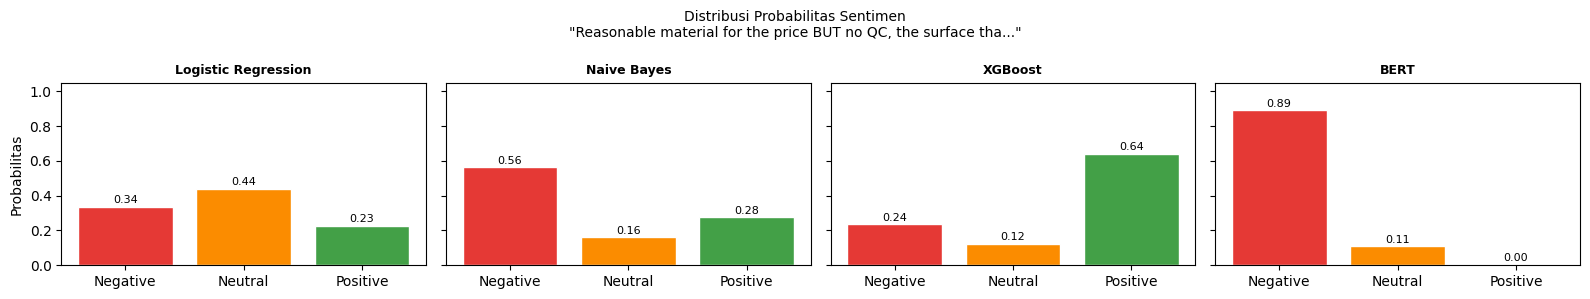


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input #4
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input teks       : "Protector came cracked in the parcel LOL, and seller ignored my messages for refund/replacement. BUY AT YOUR OWN RISK, THERES A REASON WHY ITS CHEAP!!!!"
Setelah cleaning : "protector came crack parcel lol seller ignor messag refundreplac buy risk there reason cheap"

Model                  Prediksi        Neg    Neu    Pos
-------------------------------------------------------
Logistic Regression    Negative      0.657  0.112  0.231
Naive Bayes            Negative      0.414  0.177  0.409
XGBoost                Negative      0.946  0.026  0.027
BERT                   Negative      0.999  0.001  0.001


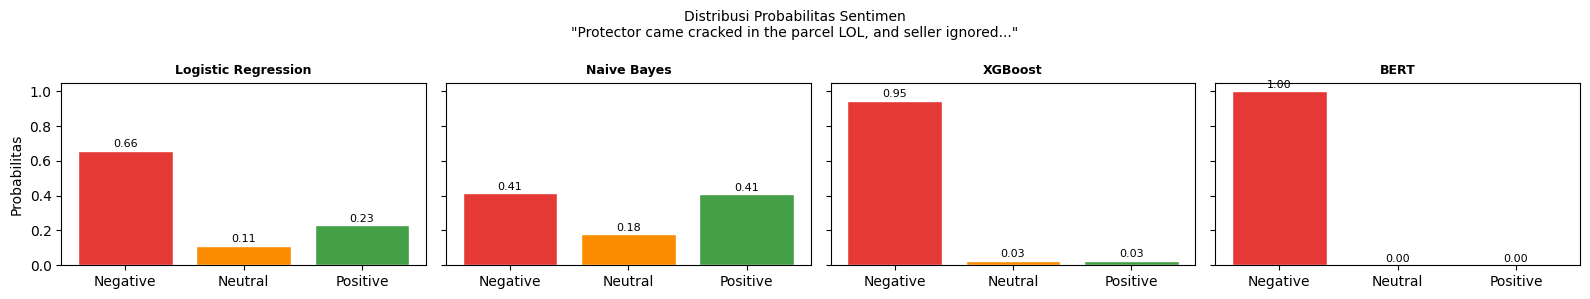


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Input #5
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Input teks       : "The colour is really nice, biege and it does not feel like cheap plastic, kindof decent. Fits in ear well, I initially thought it wouldn't but I have no difficulty wearing it. If you want a decent earbuds but at budget this is really good. Jeep is a good reputable brand."
Setelah cleaning : "colour realli nice bieg feel like cheap plastic kindof decent fit ear well initi thought wouldnt difficulti wear want decent earbud budget realli good jeep good reput brand"

Model                  Prediksi        Neg    Neu    Pos
-------------------------------------------------------
Logistic Regression    Positive      0.002  0.264  0.734
Naive Bayes            Positive      0.010  0.256  0.733
XGBoost                Positive      0.004  0.036  0.960
BERT                   Positive      0.001  0.001  0.998


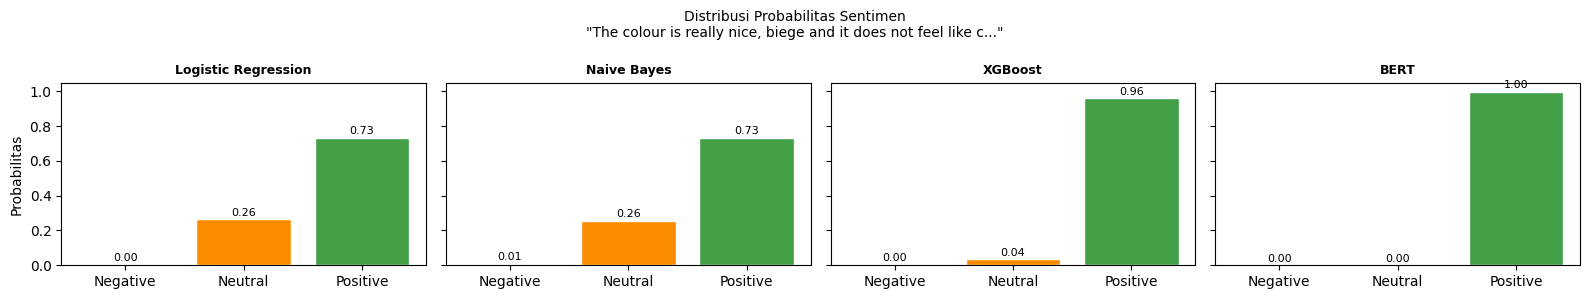

In [59]:
test_inputs = [
    "Received in a few days. Fast delivery. Nice packing. Quality is very good. Thank you seller. Will purchase again.",
    "Good and nice to use . Package no Damages , will order again",
    "Reasonable material for the price BUT no QC, the surface that adhere to the phone surface have a little rough protruded bump and thus couldn’t sit flat on the phone on the area marked with red circle in last photo.",
    "Protector came cracked in the parcel LOL, and seller ignored my messages for refund/replacement. BUY AT YOUR OWN RISK, THERES A REASON WHY ITS CHEAP!!!!",
    "The colour is really nice, biege and it does not feel like cheap plastic, kindof decent. Fits in ear well, I initially thought it wouldn't but I have no difficulty wearing it. If you want a decent earbuds but at budget this is really good. Jeep is a good reputable brand.",
]

for i, text in enumerate(test_inputs, 1):
    print(f'\n{'━'*60}')
    print(f'  Input #{i}')
    print(f'{'━'*60}')
    predict_all_models(text)